## imports

In [3]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:

from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2
from stable_baselines3 import PPO
from irc_gym.irc.model import FuncBeliefModel
import multiprocess
from ult import *

In [28]:
from auditoryforage.utils import open_pickle_file
metrics_across_blocks = open_pickle_file('/Users/yc/Downloads/metrics_across_blocks.pkl')

one_sec_in_node_units = 25/3 #3s being signal duration

metrics = ['hits_per_trial', 'misses_per_trial', 'FAs_per_trial']
colors=['green', 'blue', 'red']
block_indices_list = ['6.0', '4.0', '2.0', '5.0', '3.0', '1.0']



<Figure size 640x480 with 0 Axes>

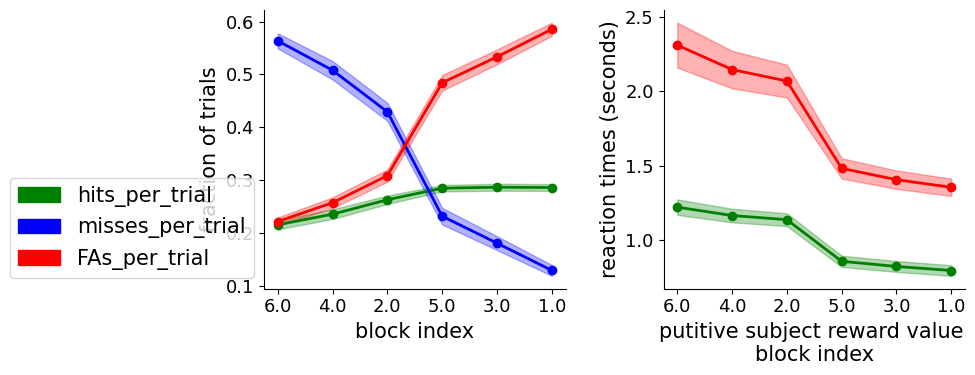

In [29]:

plt.figure()
fig, axs= plt.subplots(1,2, figsize=(10,4))

ax=axs[0]
for i, metric in enumerate(metrics):
    mean_list = [np.mean(metrics_across_blocks[block_ind][metric]) for block_ind in block_indices_list]
    sem_list = [np.std(metrics_across_blocks[block_ind][metric])/np.sqrt(len(metrics_across_blocks[block_ind][metric])) for block_ind in block_indices_list]
    mean_list, sem_list = np.array(mean_list), np.array(sem_list)
    xs=np.arange(len(block_indices_list))
    ax.plot(xs, mean_list,'-o', color=colors[i])
    ax.fill_between(xs, mean_list-sem_list, mean_list+sem_list, color=colors[i], alpha=0.3, label=metrics[i])
ax.set_xlabel('block index')
ax.set_ylabel('fraction of trials')
quickleg(ax)
ax.set_xticks(np.arange(len(block_indices_list)),block_indices_list)  # Set x-axis labels to column indices


ax=axs[1]
metrics = ['hit_reaction_time_list','fa_reaction_time_list']
colors=['green', 'red', 'red']
block_indices_list = ['6.0', '4.0', '2.0', '5.0', '3.0', '1.0']
for i, metric in enumerate(metrics):
    mean_list = [1/one_sec_in_node_units * np.mean(metrics_across_blocks[block_ind][metric]) for block_ind in block_indices_list]
    sem_list = [np.std(metrics_across_blocks[block_ind][metric])/np.sqrt(len(metrics_across_blocks[block_ind][metric])) for block_ind in block_indices_list]
    mean_list, sem_list = np.array(mean_list), np.array(sem_list)
    xs=np.arange(len(block_indices_list))
    ax.plot(xs, mean_list,'-o', color=colors[i])
    ax.fill_between(xs, mean_list-sem_list, mean_list+sem_list, color=colors[i], alpha=0.3)
ax.set_xlabel('putitive subject reward value \nblock index')
ax.set_ylabel('reaction times (seconds)')
ax.set_xticks(np.arange(len(block_indices_list)),block_indices_list)  # Set x-axis labels to column indices

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

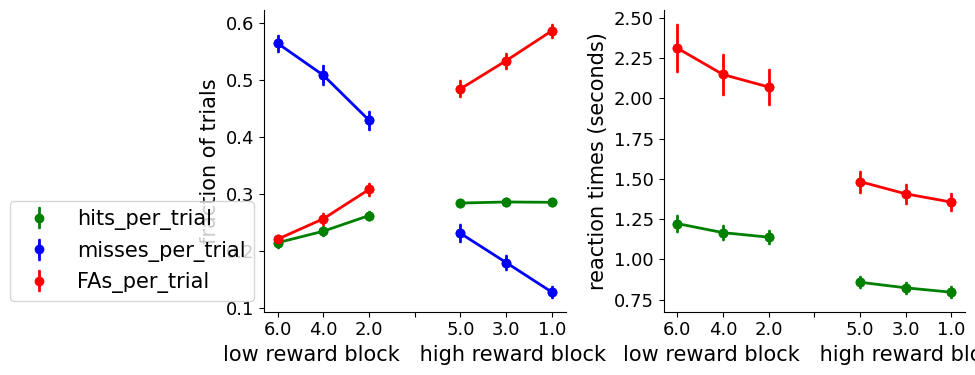

In [56]:
metrics_across_blocks = open_pickle_file('/Users/yc/Downloads/metrics_across_blocks.pkl')
one_sec_in_node_units = 25/3 #3s being signal duration
metrics = ['hits_per_trial', 'misses_per_trial', 'FAs_per_trial']
colors=['green', 'blue', 'red']
block_indices_list = ['6.0', '4.0', '2.0', '5.0', '3.0', '1.0']
xlabel_list = ['6.0', '4.0', '2.0','','' '5.0', '3.0', '1.0']


plt.figure()
fig, axs= plt.subplots(1,2, figsize=(10,4))

ax=axs[0]
for i, metric in enumerate(metrics):
    mean_list = [np.mean(metrics_across_blocks[block_ind][metric]) for block_ind in block_indices_list]
    sem_list = [np.std(metrics_across_blocks[block_ind][metric])/np.sqrt(len(metrics_across_blocks[block_ind][metric])) for block_ind in block_indices_list]

    # first block
    mean_list, sem_list = np.array(mean_list), np.array(sem_list)
    xs=np.arange(0,3)
    ax.plot(xs, mean_list[:3],'-o', color=colors[i])
    # ax.fill_between(xs[:3], (mean_list-sem_list)[:3],( mean_list+sem_list)[:3], color=colors[i], alpha=0.3, label=metrics[i])
    ax.errorbar(xs, mean_list[:3], sem_list[:3], color=colors[i], label=metrics[i],fmt='o', capsize=1)
    # next block
    xs=np.arange(4,7)
    ax.plot(xs, mean_list[3:],'-o', color=colors[i])
    # ax.fill_between(xs, (mean_list-sem_list)[3:],( mean_list+sem_list)[3:], color=colors[i], alpha=0.3, label=metrics[i])
    ax.errorbar(xs, mean_list[3:], sem_list[3:], color=colors[i], label=metrics[i],fmt='o', capsize=1)

ax.set_xlabel('low reward block   high reward block')
ax.set_ylabel('fraction of trials')
quickleg(ax)
ax.set_xticks(np.arange(len(xlabel_list)),xlabel_list)  # Set x-axis labels to column indices

ax=axs[1]
metrics = ['hit_reaction_time_list','fa_reaction_time_list']
colors=['green', 'red', 'red']
block_indices_list = ['6.0', '4.0', '2.0', '5.0', '3.0', '1.0']
for i, metric in enumerate(metrics):
    mean_list = [1/one_sec_in_node_units * np.mean(metrics_across_blocks[block_ind][metric]) for block_ind in block_indices_list]
    sem_list = [np.std(metrics_across_blocks[block_ind][metric])/np.sqrt(len(metrics_across_blocks[block_ind][metric])) for block_ind in block_indices_list]
    mean_list, sem_list = np.array(mean_list), np.array(sem_list)
    xs=np.arange(len(block_indices_list))
     # first block
    mean_list, sem_list = np.array(mean_list), np.array(sem_list)
    xs=np.arange(0,3)
    ax.plot(xs, mean_list[:3],'-o', color=colors[i])
    # ax.fill_between(xs[:3], (mean_list-sem_list)[:3],( mean_list+sem_list)[:3], color=colors[i], alpha=0.3, label=metrics[i])
    ax.errorbar(xs, mean_list[:3], sem_list[:3], color=colors[i], label=metrics[i],fmt='o', capsize=1)
    # next block
    xs=np.arange(4,7)
    ax.plot(xs, mean_list[3:],'-o', color=colors[i])
    # ax.fill_between(xs, (mean_list-sem_list)[3:],( mean_list+sem_list)[3:], color=colors[i], alpha=0.3, label=metrics[i])
    ax.errorbar(xs, mean_list[3:], sem_list[3:], color=colors[i], label=metrics[i],fmt='o', capsize=1)

ax.set_xlabel('low reward block   high reward block')
ax.set_xticks(np.arange(len(xlabel_list)),xlabel_list)  # Set x-axis labels to column indices
ax.set_ylabel('reaction times (seconds)')


plt.tight_layout()
plt.show()